### Uber ride analytics project

In [1]:
# Libraries used in this project

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import csv
import plotly.express as px

In [2]:
pwd = os.getcwd()
csv_path = os.path.join(pwd, '..', 'data', 'ncr_ride_bookings.csv')

ride_data = pd.read_csv(csv_path, encoding='latin1', on_bad_lines='skip')

ride_data.head()
ride_data.count()

Date                                 150000
Time                                 150000
Booking ID                           150000
Booking Status                       150000
Customer ID                          150000
Vehicle Type                         150000
Pickup Location                      150000
Drop Location                        150000
Avg VTAT                             139500
Avg CTAT                             102000
Cancelled Rides by Customer           10500
Reason for cancelling by Customer     10500
Cancelled Rides by Driver             27000
Driver Cancellation Reason            27000
Incomplete Rides                       9000
Incomplete Rides Reason                9000
Booking Value                        102000
Ride Distance                        102000
Driver Ratings                        93000
Customer Rating                       93000
Payment Method                       102000
dtype: int64

In [3]:
# Ensure nbformat is installed
!pip install nbformat

In [4]:
ride_data['Booking Value'] = ride_data['Booking Value']/25
ride_data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,9.48,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,25.08,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,16.64,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,29.48,48.21,4.1,4.3,UPI


In [5]:
# Draw a histogram of Booking Values
fig1 = px.histogram(ride_data, x='Booking Value', nbins=50, title='Distribution of Booking Values', labels={'Booking Value': 'Booking Value (in hundreds)'})
fig1.update_layout(xaxis_title='Booking Value (in hundreds)', yaxis_title='Frequency', bargap=0.1)
fig1.show()

# Draw a histogram of average waiting time
fig2 = px.histogram(ride_data, x='Avg VTAT', nbins=50, title='Distribution of Waiting Times', labels={'Avg VTAT': 'Waiting Time (in minutes)'})
fig2.update_layout(xaxis_title='Waiting Time (in minutes)', yaxis_title='Frequency', bargap=0.1)
fig2.show()

# Draw a histogram of average ride time
fig3 = px.histogram(ride_data, x='Avg CTAT', nbins=50, title='Distribution of Ride Times', labels={'Avg CTAT': 'Ride Time (in minutes)'})
fig3.update_layout(xaxis_title='Ride Time (in minutes)', yaxis_title='Frequency', bargap=0.1)
fig3.show()

In [6]:
# Customer Ratings
fig1 = px.histogram(
    ride_data,
    x='Customer Rating',
    nbins=50,
    title='Distribution of Customer Ratings'
)
fig1.update_traces(marker=dict(line=dict(color='black', width=1)))
fig1.update_layout(
    xaxis_title='Rating',
    yaxis_title='Frequency',
    bargap=0.05
)
fig1.show()

# Driver Ratings
fig2 = px.histogram(
    ride_data,
    x='Driver Ratings',
    nbins=50,
    title='Distribution of Driver Ratings'
)
fig2.update_traces(marker=dict(line=dict(color='black', width=1)))
fig2.update_layout(
    xaxis_title='Rating',
    yaxis_title='Frequency',
    bargap=0.05
)
fig2.show()

In [7]:
ride_data_without_cancellations = ride_data[ride_data['Incomplete Rides'] != 'NaN'].copy()

ride_data_without_cancellations['month'] = pd.to_datetime(
    ride_data_without_cancellations['Date']
).dt.to_period('M').astype(str)

ride_data_without_cancellations['week_day'] = pd.to_datetime(
    ride_data_without_cancellations['Date']
).dt.day_name()

ride_data_without_cancellations['hour'] = pd.to_datetime(
    ride_data_without_cancellations['Time']
).dt.hour

ride_data_without_cancellations['ind'] = 1


/var/folders/13/t2nx_7fx4gdd52m5jhybswv40000gn/T/ipykernel_14407/3801021737.py:11: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [8]:
monthly_data = (
    ride_data_without_cancellations
    .groupby('month')
    .agg({'Booking Value': 'sum', 'ind': 'sum'})
    .reset_index()
)

# Monthly revenue bar chart
fig_month_rev = px.bar(
    monthly_data,
    x='month',
    y='Booking Value',
    title='Monthly Revenues',
    labels={'month': 'Month', 'Booking Value': 'Revenue'}
)
fig_month_rev.update_layout(xaxis_tickangle=45)
fig_month_rev.show()

# Monthly ride volume bar chart
fig_month_vol = px.bar(
    monthly_data,
    x='month',
    y='ind',
    title='Monthly Ride Volumes',
    labels={'month': 'Month', 'ind': 'Ride Volume'}
)
fig_month_vol.update_layout(xaxis_tickangle=45)
fig_month_vol.show()

weekly_data = (
    ride_data_without_cancellations
    .groupby('week_day')
    .agg({'Booking Value': 'sum', 'ind': 'sum'})
    .reset_index()
)

# Revenue by day of week
fig_week_rev = px.bar(
    weekly_data,
    x='week_day',
    y='Booking Value',
    title='Revenues by Day of Week',
    labels={'week_day': 'Day of Week', 'Booking Value': 'Revenue'}
)
fig_week_rev.update_layout(xaxis_tickangle=45)
fig_week_rev.show()

# Ride volume by day of week
fig_week_vol = px.bar(
    weekly_data,
    x='week_day',
    y='ind',
    title='Ride Volume by Day of Week',
    labels={'week_day': 'Day of Week', 'ind': 'Ride Volume'}
)
fig_week_vol.update_layout(xaxis_tickangle=45)
fig_week_vol.show()

hourly_data = (
    ride_data_without_cancellations
    .groupby('hour')
    .agg({'Booking Value': 'sum', 'ind': 'sum'})
    .reset_index()
)

# Revenue by hour
fig_hour_rev = px.bar(
    hourly_data,
    x='hour',
    y='Booking Value',
    title='Revenues by Hour of Day',
    labels={'hour': 'Hour of Day', 'Booking Value': 'Revenue'}
)
fig_hour_rev.update_layout(xaxis_tickangle=45)
fig_hour_rev.show()

# Ride volume by hour
fig_hour_vol = px.bar(
    hourly_data,
    x='hour',
    y='ind',
    title='Ride Volume by Hour of Day',
    labels={'hour': 'Hour of Day', 'ind': 'Ride Volume'}
)
fig_hour_vol.update_layout(xaxis_tickangle=45)
fig_hour_vol.show()



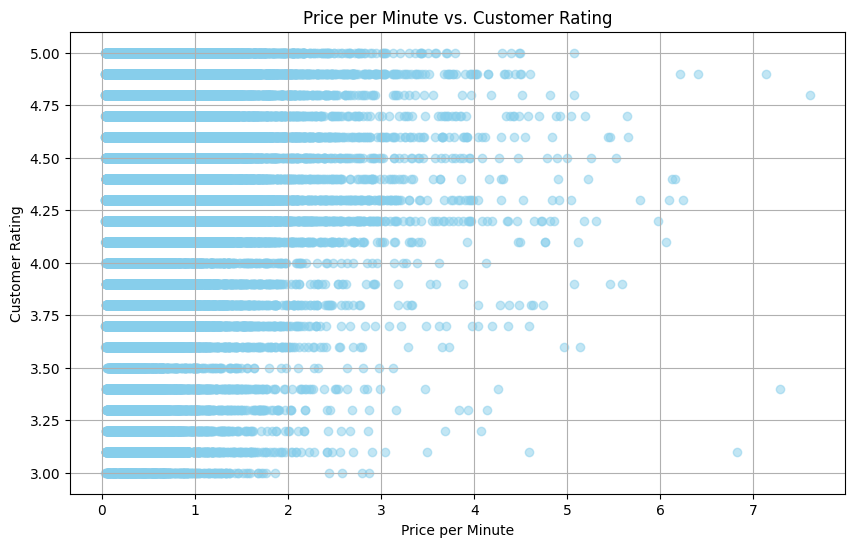

Date                                 150000
Time                                 150000
Booking ID                           150000
Booking Status                       150000
Customer ID                          150000
Vehicle Type                         150000
Pickup Location                      150000
Drop Location                        150000
Avg VTAT                             139500
Avg CTAT                             102000
Cancelled Rides by Customer           10500
Reason for cancelling by Customer     10500
Cancelled Rides by Driver             27000
Driver Cancellation Reason            27000
Incomplete Rides                       9000
Incomplete Rides Reason                9000
Booking Value                        102000
Ride Distance                        102000
Driver Ratings                        93000
Customer Rating                       93000
Payment Method                       102000
month                                150000
week_day                        

In [9]:
# Customer satisfaction analysis

ride_data_without_cancellations['total_ride_length'] = ride_data_without_cancellations['Avg VTAT'] + ride_data_without_cancellations['Avg CTAT']
ride_data_without_cancellations['price_per_minute'] = ride_data_without_cancellations['Booking Value'] / ride_data_without_cancellations['total_ride_length']

# Scatter plot of price per minute vs. customer rating
plt.figure(figsize=(10,6))
plt.scatter(ride_data_without_cancellations['price_per_minute'], ride_data_without_cancellations['Customer Rating'], alpha=0.5, color='skyblue')
plt.title('Price per Minute vs. Customer Rating')
plt.xlabel('Price per Minute')
plt.ylabel('Customer Rating')
plt.grid(True)
plt.show()

ride_data_without_cancellations.count()